In [1]:
# import community as community_louvain
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import networkx as nx
import numpy as np
import random
from collections import Counter, defaultdict
from networkx.algorithms import community

G = nx.read_edgelist("data/Email-Enron.txt", nodetype=int)

print("Number of nodes:", G.number_of_nodes())
print("Number of edges:", G.number_of_edges())

Number of nodes: 36692
Number of edges: 183831


In [2]:
# Analyze the nodes centrality in each graph using different notions of centrality (e.g. degree centrality, betweenness centrality, eigenvector centrality etc.). What are the most central nodes in each graph? Why might that be the case?
deg_cent = nx.degree_centrality(G)
bet_cent = nx.betweenness_centrality(G, k=500, seed=42)
eig_cent = nx.pagerank(G, alpha=0.85)

# find top 5 nodes
def top_k(centrality_dict, k=5):
    return sorted(centrality_dict.items(), key=lambda x: x[1], reverse=True)[:k]

print(f"Top 5 Degree Centrality: {top_k(deg_cent)}")
print(f"Top 5 Betweenness Centrality: {top_k(bet_cent)}")
print(f"Top 5 Eigenvector Centrality: {top_k(eig_cent)}")

Top 5 Degree Centrality: [(5038, 0.03769316726172631), (273, 0.037257093020086667), (458, 0.034368101169224057), (140, 0.033932026927584416), (1028, 0.03390477228748194)]
Top 5 Betweenness Centrality: [(5038, 0.06449935698326253), (140, 0.05726598613239822), (823, 0.0390973676327165), (566, 0.03734999817799342), (1139, 0.03537511935909608)]
Top 5 Eigenvector Centrality: [(5038, 0.011403033206419748), (273, 0.003228111394184455), (140, 0.0030076300160099697), (458, 0.002957082468897517), (588, 0.0029295871965246655)]


In [3]:
# How many nodes are among the top 10% in terms of degree centrality AND betweenness centrality? How does this overlap change for each of these networks?
k = int(0.10 * len(G.nodes()))

top_deg = set([node for node, val in sorted(deg_cent.items(), key=lambda x: x[1], reverse=True)[:k]])
top_bet = set([node for node, val in sorted(bet_cent.items(), key=lambda x: x[1], reverse=True)[:k]])

overlap = top_deg.intersection(top_bet)

print(f"{len(overlap)} nodes overlap in top 10% ({len(overlap)/k * 100:.2f}% overlap)")

2361 nodes overlap in top 10% (64.35% overlap)


Louvain found 1265 distinct communities.
-> Fluid Communities successfully forced 5 communities in the LCC.


/var/folders/70/xcmvqsj57kj0hhxl81k3t4s40000gn/T/ipykernel_56892/3606094670.py:53: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('viridis', len(macro_G.nodes()))


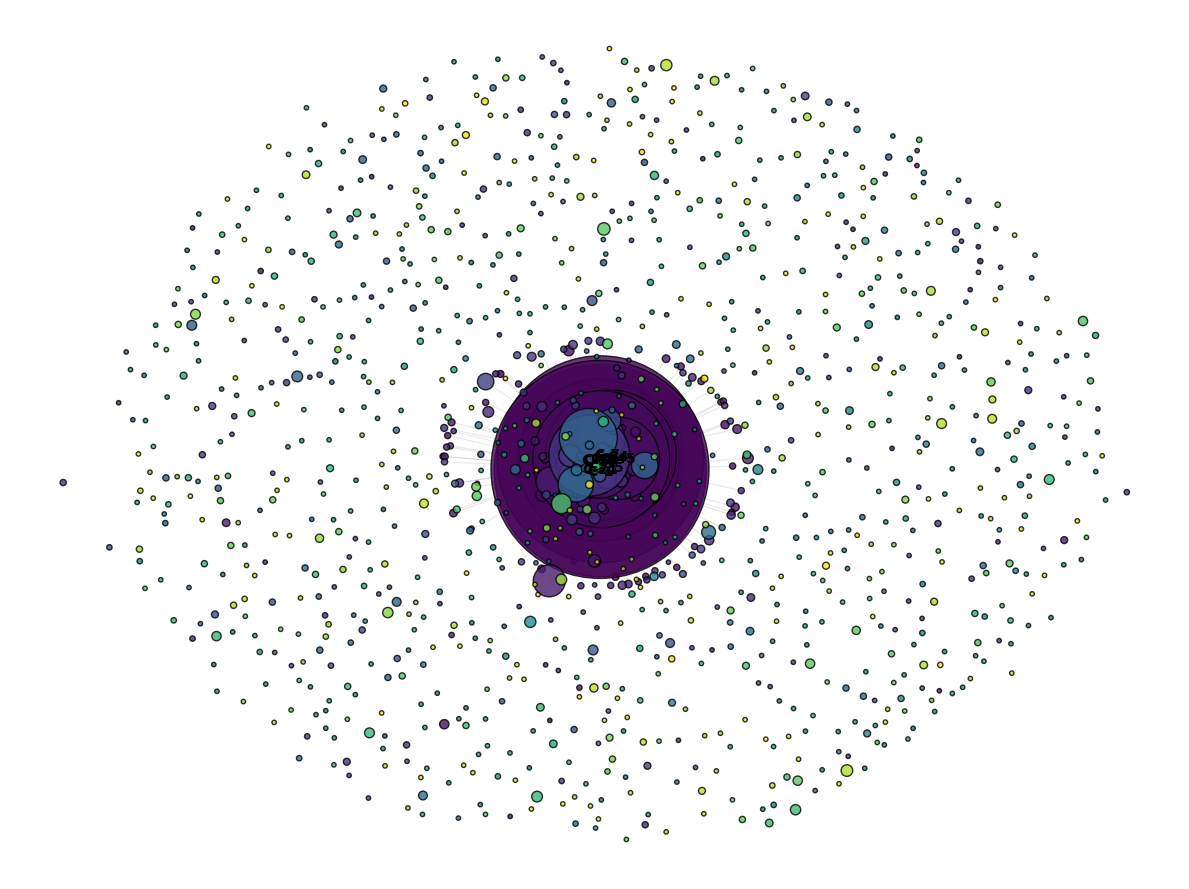

In [4]:
# Perform community detection on these graphs. Investigate different community detection algorithms (e.g. “Louvain algorithm.” ). Experiment with bounded and unbounded approaches. Visualize results.
G_clean = G.to_undirected()
G_clean.remove_edges_from(nx.selfloop_edges(G_clean))

louvain_comms = community.louvain_communities(G_clean, seed=42)
print(f"Louvain found {len(louvain_comms)} distinct communities.")

louvain_partition = {}
for i, comm in enumerate(louvain_comms):
    for node in comm:
        louvain_partition[node] = i

lcc_nodes = max(nx.connected_components(G_clean), key=len)
G_lcc = G_clean.subgraph(lcc_nodes)

k_communities = 5
try:
    fluid_comms = list(community.asyn_fluidc(G_lcc, k=k_communities, seed=42))
    print(f"-> Fluid Communities successfully forced {len(fluid_comms)} communities in the LCC.")
except Exception as e:
    print(f"-> Fluid Communities failed (likely due to structural limits): {e}")

macro_G = nx.Graph()

comm_sizes = Counter(louvain_partition.values())
for comm_id, size in comm_sizes.items():
    macro_G.add_node(comm_id, size=size)

edge_weights = Counter()
for u, v in G.edges():
    comm_u = louvain_partition.get(u)
    comm_v = louvain_partition.get(v)
    if comm_u is not None and comm_v is not None and comm_u != comm_v:
        edge = tuple(sorted((comm_u, comm_v)))
        edge_weights[edge] += 1

for (comm_u, comm_v), weight in edge_weights.items():
    macro_G.add_edge(comm_u, comm_v, weight=weight)

# 3. Draw the graph
plt.figure(figsize=(12, 9))

# Spring layout pushes weakly connected communities apart
pos = nx.spring_layout(macro_G, k=0.5, seed=42)

# Scale node sizes for the plot
node_sizes = [macro_G.nodes[n]['size'] * 5 for n in macro_G.nodes()]

# Scale edge widths (logarithmic scale prevents massive edges from taking over the screen)
edge_widths = [np.log(macro_G.edges[e]['weight'] + 1) for e in macro_G.edges()]

# Color mapping
cmap = cm.get_cmap('viridis', len(macro_G.nodes()))
node_colors = [cmap(i) for i in range(len(macro_G.nodes()))]

# Plotting
nx.draw_networkx_nodes(macro_G, pos, node_size=node_sizes, node_color=node_colors, alpha=0.8, edgecolors='black')
nx.draw_networkx_edges(macro_G, pos, width=edge_widths, alpha=0.2, edge_color='gray')

# Only label the top 10 largest communities to avoid text clutter
top_comms = [comm for comm, size in comm_sizes.most_common(10)]
labels = {n: f"C-{n}" for n in top_comms}
nx.draw_networkx_labels(macro_G, pos, labels=labels, font_size=10, font_weight='bold')

# plt.title("title", fontsize=16)
plt.axis('off')
plt.tight_layout()
plt.show()

In [5]:
# Analyze the communities formed as a result of the community detection algorithms. Why do certain nodes belong to the same community? For example, for the Erd¨os graph, one can analyze the top 5 authors with highest degree from the largest communities and check their research areas to see if they indeed have shared research interests.
comm_dict = defaultdict(list)
for node, comm_id in louvain_partition.items():
    comm_dict[comm_id].append(node)

largest_comm_id = max(comm_dict, key=lambda k: len(comm_dict[k]))
largest_comm_nodes = comm_dict[largest_comm_id]

H = G.subgraph(largest_comm_nodes)

deg_cent = nx.degree_centrality(H)
top_5 = sorted(deg_cent.items(), key=lambda x: x[1], reverse=True)[:5]

print(f"Largest Community (ID {largest_comm_id}) has {len(largest_comm_nodes)} nodes.")
print(f"Top 5 highest degree nodes in this community: {top_5}")

Largest Community (ID 21) has 4928 nodes.
Top 5 highest degree nodes in this community: [(273, 0.2167647655774305), (1028, 0.1907854678303227), (370, 0.16074690481022935), (1139, 0.12056017860767201), (136, 0.0891008727420337)]


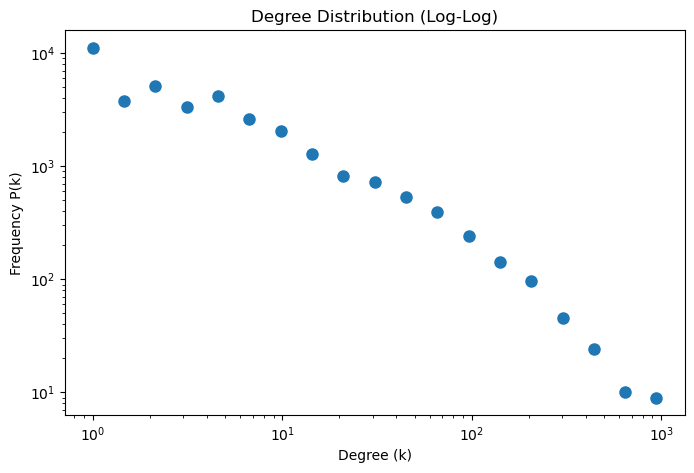

In [6]:
# Analyze the degree distribution of these graphs. Do they follow a power law or a Poisson degree distribution? Why or why not?
degrees = [d for n, d in G.degree()]

plt.figure(figsize=(8, 5))

# Plot log-log distribution
hist, bins = np.histogram(degrees, bins=np.logspace(np.log10(min(degrees)), np.log10(max(degrees)), 20))
plt.loglog(bins[:-1], hist, 'o', markersize=8)

plt.title(f"Degree Distribution (Log-Log)")
plt.xlabel("Degree (k)")
plt.ylabel("Frequency P(k)")
plt.show()

In [7]:
# Calculate the diameter and the average shortest path for these graphs. What can you notice?
sample_size = 100

LCC = G.subgraph(max(nx.connected_components(G), key=len))

sampled_nodes = random.sample(list(LCC.nodes()), sample_size)

path_lengths = []
max_path = 0

# Only calculate paths originating from the sampled nodes
for node in sampled_nodes:
    # returns dict of {target: path_length}
    lengths = nx.single_source_shortest_path_length(LCC, node)

    path_lengths.extend(lengths.values())
    max_path = max(max_path, max(lengths.values()))

# Calculate averages from the sample
avg_path = sum(path_lengths) / len(path_lengths)

# Note: Max path from a sample is a lower-bound estimate of the true diameter
print(f"Estimated Average Shortest Path: {avg_path:.2f}")
print(f"Estimated Diameter (Lower Bound): {max_path}")

Estimated Average Shortest Path: 4.01
Estimated Diameter (Lower Bound): 11


In [8]:
# In terms of similarity and performance, how would you compare these graphs to Barabasi-Albert, Watts-Strogatz and Erd¨os-Renyi graphs? Justify your reasoning.
N = G.number_of_nodes()
M = G.number_of_edges()
avg_k = int(2 * M / N)

p = 2 * M / (N * (N - 1))
ER = nx.erdos_renyi_graph(N, p)

BA = nx.barabasi_albert_graph(N, max(1, avg_k // 2))

WS = nx.watts_strogatz_graph(N, max(2, avg_k), 0.1)

print(f"Empirical Graph Clustering: {nx.average_clustering(G):.4f}")
print(f"ER Graph Clustering: {nx.average_clustering(ER):.4f}")
print(f"BA Graph Clustering: {nx.average_clustering(BA):.4f}")
print(f"WS Graph Clustering: {nx.average_clustering(WS):.4f}")

Empirical Graph Clustering: 0.4970
ER Graph Clustering: 0.0003
BA Graph Clustering: 0.0023
WS Graph Clustering: 0.4901
